# Análisis de demoras en envíos – DataCo Supply Chain Análisis de la demora real vs. programada en envíos

 ## Carga y preparación de datos Se carga el dataset de DataCo Supply Chain
 se realizan las conversiones necesarias antes de analizar: tipado de columnas de fecha y cálculo de la demora por pedido.

In [1]:
import pandas as pd

In [33]:
import matplotlib.pyplot as plt

In [3]:
df_SuppChain = pd.read_csv(r'DataCoSupplyChainDatasetEXCEL.csv',delimiter=';',encoding='latin1')

In [14]:
df_SuppChain['shipping date (DateOrders)'] = pd.to_datetime(df_SuppChain['shipping date (DateOrders)'])

In [12]:
df_SuppChain['order date (DateOrders)'] = pd.to_datetime(df_SuppChain['order date (DateOrders)']) 

df_SuppChain.info()

In [18]:
df_SuppChain['dias_demora']= (df_SuppChain['Days for shipping (real)'] - df_SuppChain['Days for shipment (scheduled)'])

In [20]:
df_SuppChain['dias_demora'].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: dias_demora, dtype: float64

## Distribución de la demora por pedido 
Distribución de la demora por pedido
El promedio general de demora es de 0,57 días, pero un promedio no muestra la dispersión real de los datos. El siguiente histograma visualiza cómo se distribuye la demora pedido por pedido, para detectar si ese promedio esconde variabilidad.

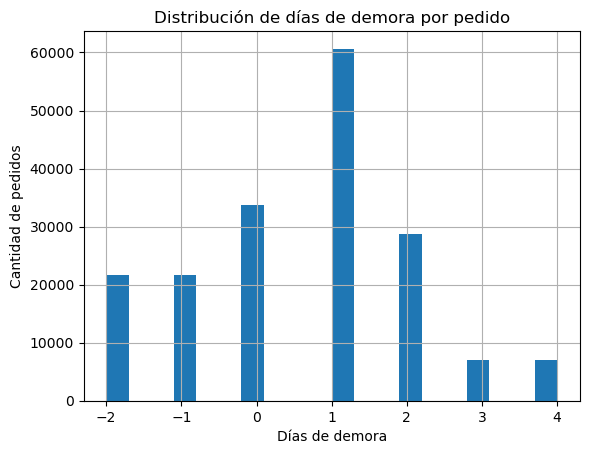

In [30]:
df_SuppChain['dias_demora'].hist(bins=20)
plt.title('Distribución de días de demora por pedido')
plt.xlabel('Días de demora')
plt.ylabel('Cantidad de pedidos')
plt.show()

## Conclusión del cuadro final
First Class tiene mal promedio pero es consistente (siempre falla igual, fácil de diagnosticar). Standard Class tiene buen promedio pero es errático (impredecible, más difícil de gestionar operativamente aunque "en papel" cumpla).

In [32]:
df_SuppChain.groupby('Shipping Mode')['dias_demora'].agg(
    Promedio='mean',
    Desvio_Estandar='std',
    Minimo='min',
    Maximo='max'
)

,Promedio,Desvio_Estandar,Minimo,Maximo
Shipping Mode,,,,
First Class,1.000000,0.000000,1,1
Same Day,0.478279,0.499554,0,1
Second Class,1.990828,1.415900,0,4
Standard Class,-0.004093,1.417266,-2,2
